## Generación de Conjunto de datos con fallas trifasicas de la A - G

In [1]:
import numpy as np
import pandas as pd
import os
import random
import time
import cmath # Para matemática compleja

# ==============================================================================
# 1. PARÁMETROS
# ==============================================================================
FS = 7200
FREQ = 60
AMPLITUDE = 1.0
DURATION = 1
N_SAMPLES_PER_CLASS = 4100
N_NOISY = 1100
SNR_DB_RANGE = (25, 40)
# ¡NUEVO! Nombre de archivo más descriptivo
OUTPUT_PARQUET_FILE = "Dataset_Trifasico_5.parquet"

# ==============================================================================
# 2. FUNCIONES AUXILIARES (Sin cambios)
# ==============================================================================

def generar_señal_trifasica_base(duration=DURATION, fs=FS, freq=FREQ, amplitude=AMPLITUDE):
    """Genera las tres fases de una señal senoidal pura y balanceada."""
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    phase_a = amplitude * np.sin(2 * np.pi * freq * t)
    phase_b = amplitude * np.sin(2 * np.pi * freq * t - 2 * np.pi / 3)
    phase_c = amplitude * np.sin(2 * np.pi * freq * t + 2 * np.pi / 3)
    return t, phase_a, phase_b, phase_c

def añadir_ruido_snr(signal, snr_db):
    """Añade ruido gaussiano a una señal para alcanzar un SNR específico."""
    signal_power = np.mean(signal**2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), len(signal))
    return signal + noise

# ==============================================================================
# 3. FUNCIÓN DE GENERACIÓN (¡MEJORADA!)
# ==============================================================================

def generar_evento_sag_final_generalizado(t, sag_type, fs=FS, freq=FREQ, amplitude=AMPLITUDE):
    """
    Versión 100% CORREGIDA que implementa fielmente las ecuaciones del paper,
    corrige el bug de aplicación de ángulos y generaliza correctamente.
    """
    duration_cycles = random.uniform(2, 15)
    sag_duration_s = duration_cycles / freq
    start_time = random.uniform(0.05, DURATION - sag_duration_s - 0.05)
    end_time = start_time + sag_duration_s
    u = (t >= start_time) & (t < end_time)

    t_inicio_idx = int(start_time * fs)
    t_fin_idx = int(end_time * fs)

    va_sag = amplitude * np.sin(2 * np.pi * freq * t)
    vb_sag = amplitude * np.sin(2 * np.pi * freq * t - 2 * np.pi / 3)
    vc_sag = amplitude * np.sin(2 * np.pi * freq * t + 2 * np.pi / 3)
    
    V = random.uniform(0.1, 0.9)
    j = 1j
    a = cmath.exp(j * 2 * np.pi / 3) # Operador Fortescue 'a'
    fase_shift_delta = np.deg2rad(random.uniform(5, 25)) 
    
       # --- Lógica para Tipo F (Trifásico Desbalanceado) ---
    # 1. Empezamos con los fasores de un sag trifásico balanceado
    fasores_f = {'A': V, 'B': V * a**2, 'C': V * a}
    
    # 2. Elegimos 2 de las 3 fases al azar para aplicarles un desfase
    phases_to_shift = random.sample(['A', 'B', 'C'], 2)
    
    # 3. Creamos dos fasores de desfase (magnitud 1, ángulo aleatorio)
    shift_1 = cmath.exp(j * np.deg2rad(random.uniform(-15, 15)))
    shift_2 = cmath.exp(j * np.deg2rad(random.uniform(-15, 15)))
    
    # 4. Aplicamos los desfases a las fases seleccionadas
    fasores_f[phases_to_shift[0]] *= shift_1
    fasores_f[phases_to_shift[1]] *= shift_2
    # ==========================================================================
    # =========== ¡DICCIONARIO 100% FIEL A LA TABLA DEL PAPER! =============
    # ==========================================================================
    # Implementación directa de las ecuaciones que proporcionaste
    phasors_base = {
        # Tipo A: Trifásico Balanceado
        'A': [V, -0.5*V - j*(np.sqrt(3)/2)*V, -0.5*V + j*(np.sqrt(3)/2)*V],
        
        # Tipo B
        'B': [V, -0.5 - j*(np.sqrt(3)/2), -0.5 + j*(np.sqrt(3)/2)],
        
        # Tipo C: 
        'C': [1, -0.5 - j*(np.sqrt(3)/2)*V , -0.5 + j*(np.sqrt(3)/2)*V],
        
        # Tipo D
        'D': [V, 1.0 * cmath.exp(j * (-2*np.pi/3 + fase_shift_delta)), 1.0 * cmath.exp(j * (2*np.pi/3 - fase_shift_delta))],
        
        # Tipo E: 
        'E': [1, -0.5*V - j*(np.sqrt(3)/2)*V, -0.5*V + j*(np.sqrt(3)/2)*V],
        
        # Tipo F
        'F': [fasores_f['A'], fasores_f['B'], fasores_f['C']],
        
        # Tipo G: 
        'G': [2/3 + (1/3)*V  , -1/3 -1/6 - j*(np.sqrt(3)/2)*V, -1/3 -1/6 + j*(np.sqrt(3)/2)*V]
    }
    
    
    va_phasor, vb_phasor, vc_phasor = phasors_base[sag_type]
    
    # --- ¡LÓGICA DE ROTACIÓN CORREGIDA! ---
    # Rota todas las fallas que NO son trifásicas (asimétricas)
    if sag_type != 'A':
        rotacion = random.choice([0, 120, 240])
        if rotacion == 120: # Rota A->B, B->C, C->A
            va_phasor, vb_phasor, vc_phasor = vc_phasor, va_phasor, vb_phasor
        elif rotacion == 240: # Rota A->C, C->B, B->A
            va_phasor, vb_phasor, vc_phasor = vb_phasor, vc_phasor, va_phasor

    mag_a, ang_a = cmath.polar(va_phasor)
    mag_b, ang_b = cmath.polar(vb_phasor)
    mag_c, ang_c = cmath.polar(vc_phasor)

    # ==========================================================================
    # =========== ¡APLICACIÓN DE ÁNGULOS 100% CORREGIDA! =============
    # ==========================================================================
    va_sag[u] = amplitude * mag_a * np.sin(2 * np.pi * freq * t[u] + ang_a)
    vb_sag[u] = amplitude * mag_b * np.sin(2 * np.pi * freq * t[u] - (2*np.pi/3) + ang_b)
    vc_sag[u] = amplitude * mag_c * np.sin(2 * np.pi * freq * t[u] + (2*np.pi/3) + ang_c)
    
    return va_sag, vb_sag, vc_sag, t_inicio_idx, t_fin_idx
# ==============================================================================
# 4. BUCLE PRINCIPAL (¡MEJORADO!)
# ==============================================================================
if __name__ == "__main__":
    start_total_time = time.time()
    clases_de_fallas = ['Normal', 'Sag_A', 'Sag_B', 'Sag_C', 'Sag_D', 'Sag_E', 'Sag_F', 'Sag_G']
    all_signals_data = []

    for clase in clases_de_fallas:
        print(f"--- Generando clase: {clase} ---")
        for i in range(1, N_SAMPLES_PER_CLASS + 1):
            t = np.linspace(0, DURATION, int(FS * DURATION), endpoint=False)
            
            if clase != 'Normal':
                sag_type = clase.split('_')[1]
                # ¡MODIFICADO! Captura los 5 valores que ahora devuelve la función
                va, vb, vc, t_inicio, t_fin = generar_evento_sag_final_generalizado(t, sag_type, fs=FS)
            else:
                _, va, vb, vc = generar_señal_trifasica_base()
                # ¡NUEVO! Para la clase Normal, no hay evento. Usamos -1 como marcador.
                t_inicio, t_fin = -1, -1
            
            is_noisy = i <= N_NOISY
            if is_noisy:
                snr = random.uniform(SNR_DB_RANGE[0], SNR_DB_RANGE[1])
                va = añadir_ruido_snr(va, snr)
                vb = añadir_ruido_snr(vb, snr)
                vc = añadir_ruido_snr(vc, snr)
                signal_id = f"{clase}_noisy_{i:04d}"
            else:
                signal_id = f"{clase}_clean_{i - N_NOISY:04d}"
            
            # ¡MODIFICADO! Añade las columnas nuevas al DataFrame al guardar
            signal_df = pd.DataFrame({
                'signal_id': signal_id, 
                'etiqueta': clase, 
                'timestamp': t, 
                'Phase_A': va, 
                'Phase_B': vb, 
                'Phase_C': vc,
            })
            all_signals_data.append(signal_df)

        print(f"   Generadas {N_SAMPLES_PER_CLASS} señales para la clase {clase}.")

    print("\nConcatenando y guardando el dataset final...")
    final_df = pd.concat(all_signals_data, ignore_index=True)
    final_df.to_parquet(OUTPUT_PARQUET_FILE, index=False)
    
    end_total_time = time.time()
    print(f"\n¡Dataset final completado en {(end_total_time - start_total_time) / 60:.2f} minutos!")

--- Generando clase: Normal ---
   Generadas 4100 señales para la clase Normal.
--- Generando clase: Sag_A ---
   Generadas 4100 señales para la clase Sag_A.
--- Generando clase: Sag_B ---
   Generadas 4100 señales para la clase Sag_B.
--- Generando clase: Sag_C ---
   Generadas 4100 señales para la clase Sag_C.
--- Generando clase: Sag_D ---
   Generadas 4100 señales para la clase Sag_D.
--- Generando clase: Sag_E ---
   Generadas 4100 señales para la clase Sag_E.
--- Generando clase: Sag_F ---
   Generadas 4100 señales para la clase Sag_F.
--- Generando clase: Sag_G ---
   Generadas 4100 señales para la clase Sag_G.

Concatenando y guardando el dataset final...

¡Dataset final completado en 1.39 minutos!


## Visualizar algunos metadatos

In [2]:
import pandas as pd
import pyarrow.parquet as pq
from collections import defaultdict

# 1.  ruta archivo Parquet
file_path = r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Generacion_Señales\Trifasico\Dataset_Trifasico_3.parquet"

# 2. Número de ejemplos a ver por cada clase
EXAMPLES_PER_CLASS = 3

try:
    print(f"Abriendo el archivo: {file_path}...")
    parquet_file = pq.ParquetFile(file_path)

    # Diccionario para guardar los ejemplos encontrados
    class_examples = defaultdict(set)
    # Contadores
    total_signals = set()
    
    print("Analizando el archivo para encontrar señales y clases...")
    # 3. Itera sobre los trozos del archivo (row groups)
    for i in range(parquet_file.num_row_groups):
        # Lee solo las columnas necesarias de cada trozo
        group_table = parquet_file.read_row_group(i, columns=['signal_id', 'etiqueta'])
        group_df = group_table.to_pandas()

        # Agrupa por clase y encuentra los IDs únicos en este trozo
        for clase, data in group_df.groupby('etiqueta'):
            # Añade los IDs únicos al contador total
            total_signals.update(data['signal_id'].unique())
            
            # Si aún no tenemos suficientes ejemplos para esta clase, los añadimos
            if len(class_examples[clase]) < EXAMPLES_PER_CLASS:
                # Toma hasta 3 IDs únicos de este trozo
                ids_to_add = data['signal_id'].unique()[:EXAMPLES_PER_CLASS]
                class_examples[clase].update(ids_to_add)

        # Opcional: Si ya encontramos ejemplos para las 8 clases, podemos parar
        if len(class_examples) == 8:
             # Continuamos leyendo para obtener el conteo total, pero no más ejemplos
             pass


    # 4. Imprime los resultados
    print("\n--- Resumen del Contenido del Dataset ---")
    print(f"Total de clases únicas encontradas: {len(class_examples)}")
    print(f"Total de señales únicas encontradas: {len(total_signals)} (deberían ser 32800)")

    print("\n--- Ejemplos de 'signal_id' por cada clase ---")
    for clase in sorted(class_examples.keys()):
        print(f"\nClase: {clase}")
        # Toma los primeros N ejemplos de la lista para esta clase
        examples_to_show = list(class_examples[clase])[:EXAMPLES_PER_CLASS]
        for signal_id in examples_to_show:
            print(f"  - {signal_id}")

except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {file_path}")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo: {e}")

Abriendo el archivo: C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Generacion_Señales\Trifasico\Dataset_Trifasico_3.parquet...
Analizando el archivo para encontrar señales y clases...


KeyboardInterrupt: 

## Graficas de Señales Trifasicas

Cargando el dataset desde: Dataset_Trifasico_5.parquet...
Buscando y graficando la señal con ID: Sag_A_clean_0011...


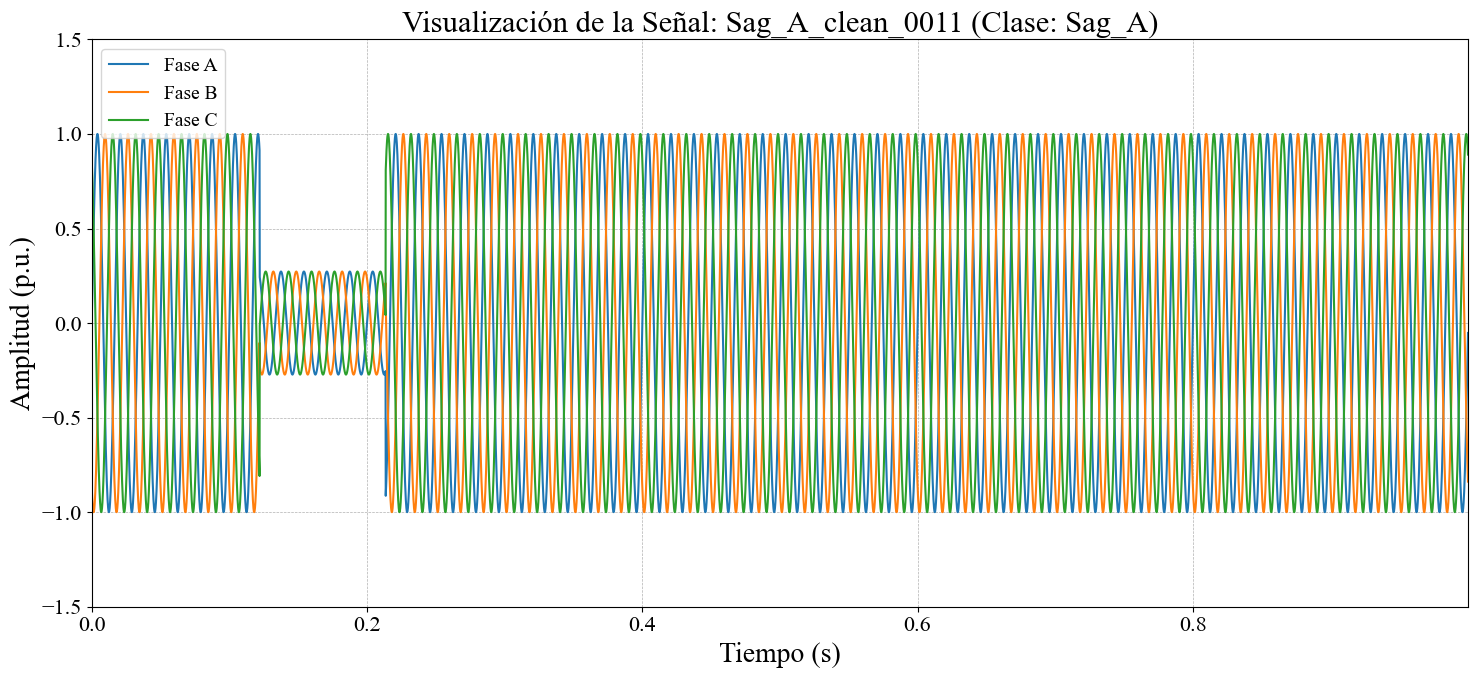

Cargando el dataset desde: Dataset_Trifasico_5.parquet...
Buscando y graficando la señal con ID: Sag_B_clean_0011...


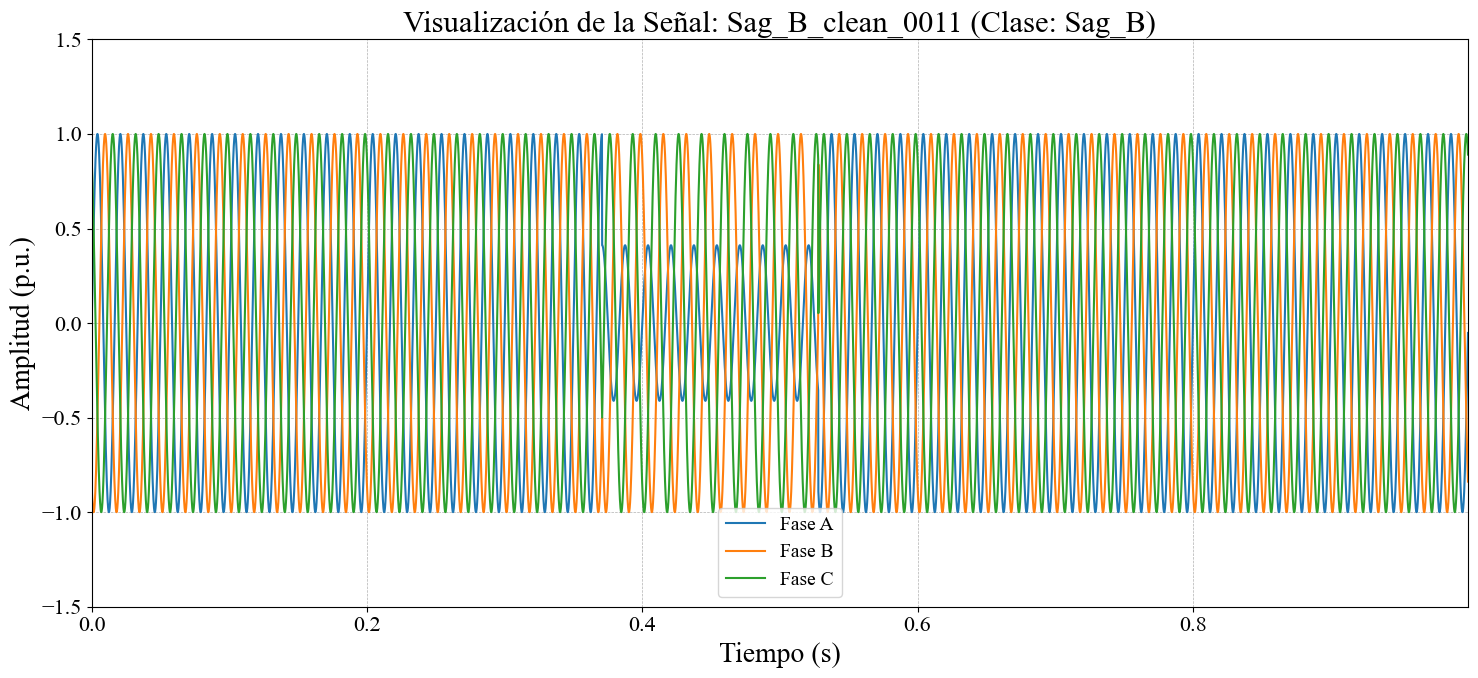

Cargando el dataset desde: Dataset_Trifasico_5.parquet...
Buscando y graficando la señal con ID: Sag_C_clean_0011...


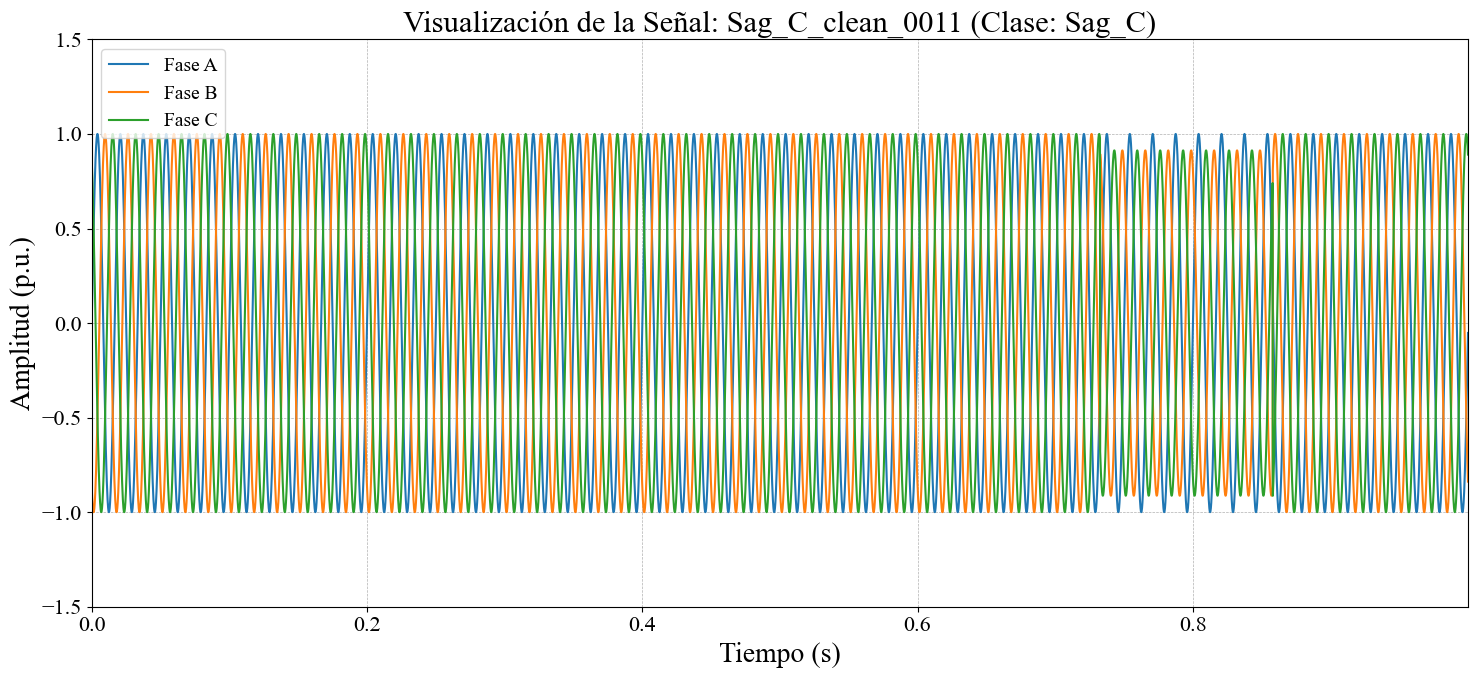

Cargando el dataset desde: Dataset_Trifasico_5.parquet...
Buscando y graficando la señal con ID: Sag_D_clean_0011...


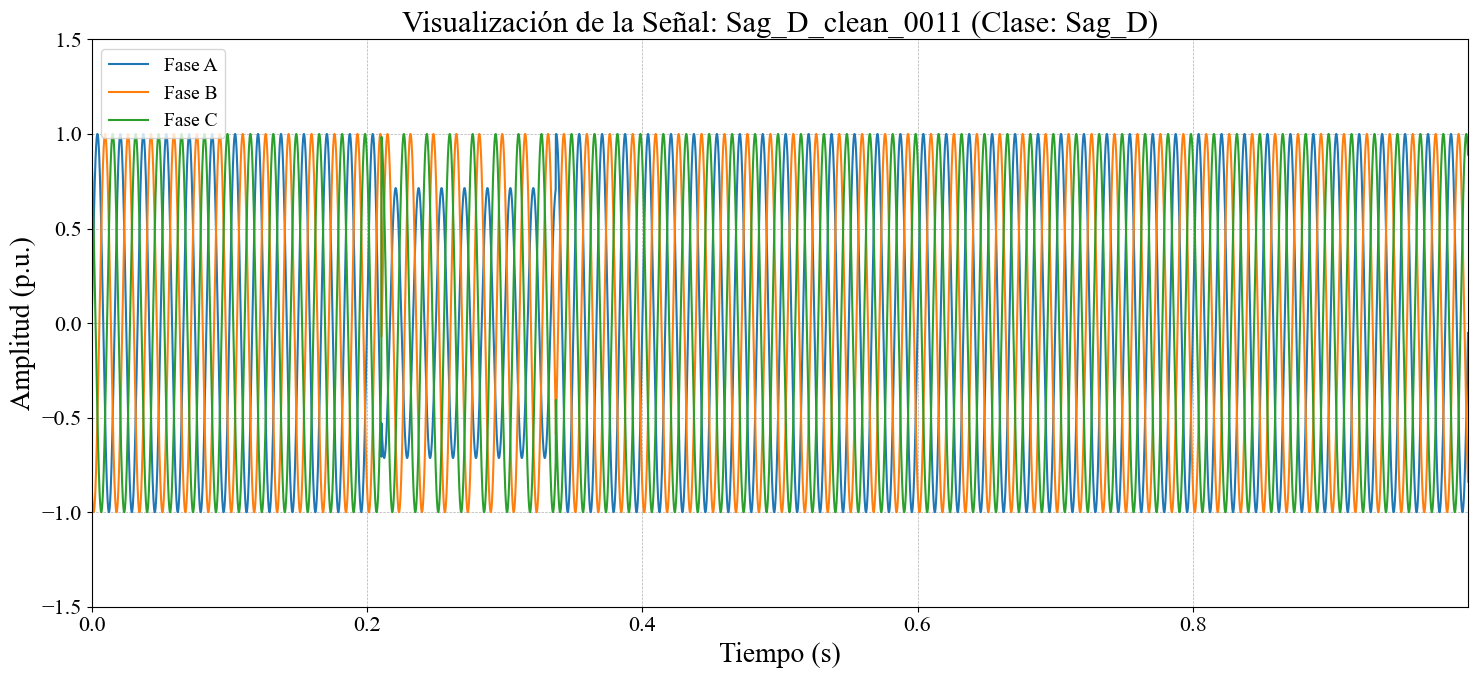

Cargando el dataset desde: Dataset_Trifasico_5.parquet...
Buscando y graficando la señal con ID: Sag_E_clean_0011...


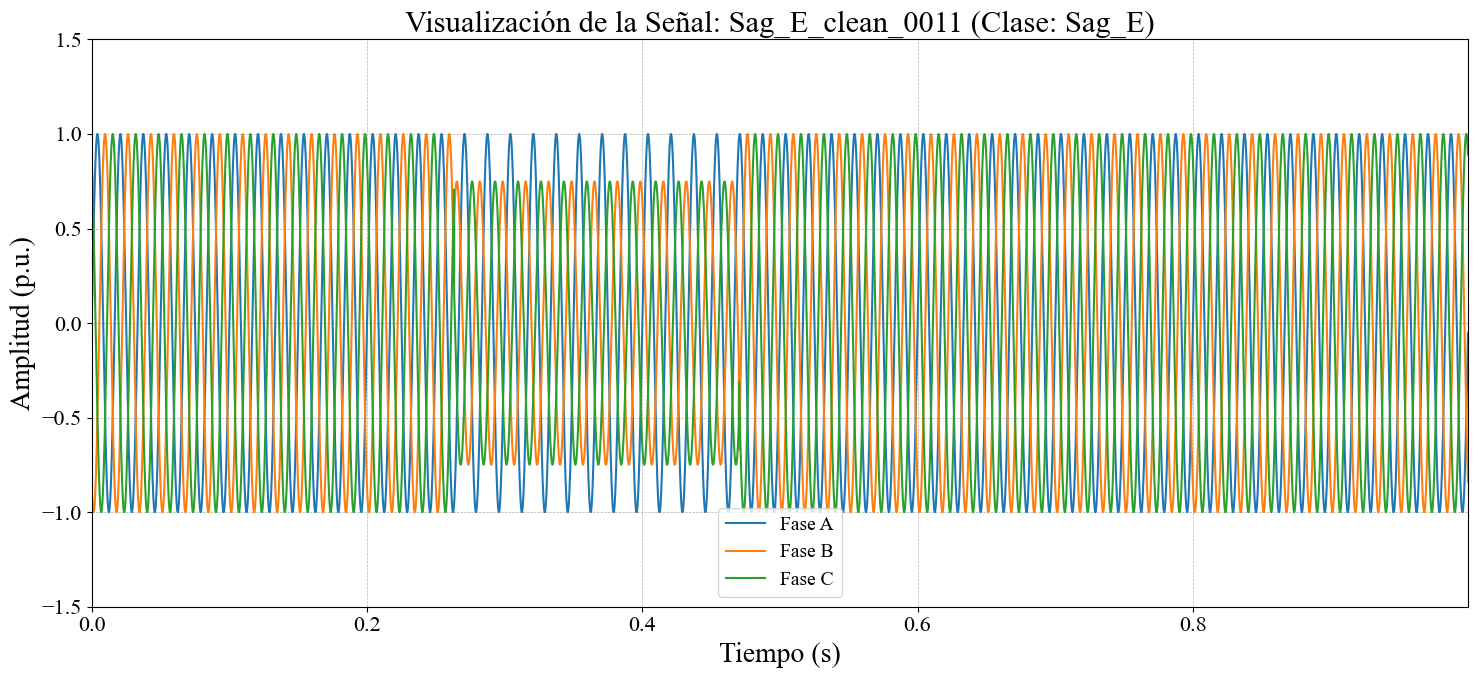

Cargando el dataset desde: Dataset_Trifasico_5.parquet...
Buscando y graficando la señal con ID: Sag_F_clean_0011...


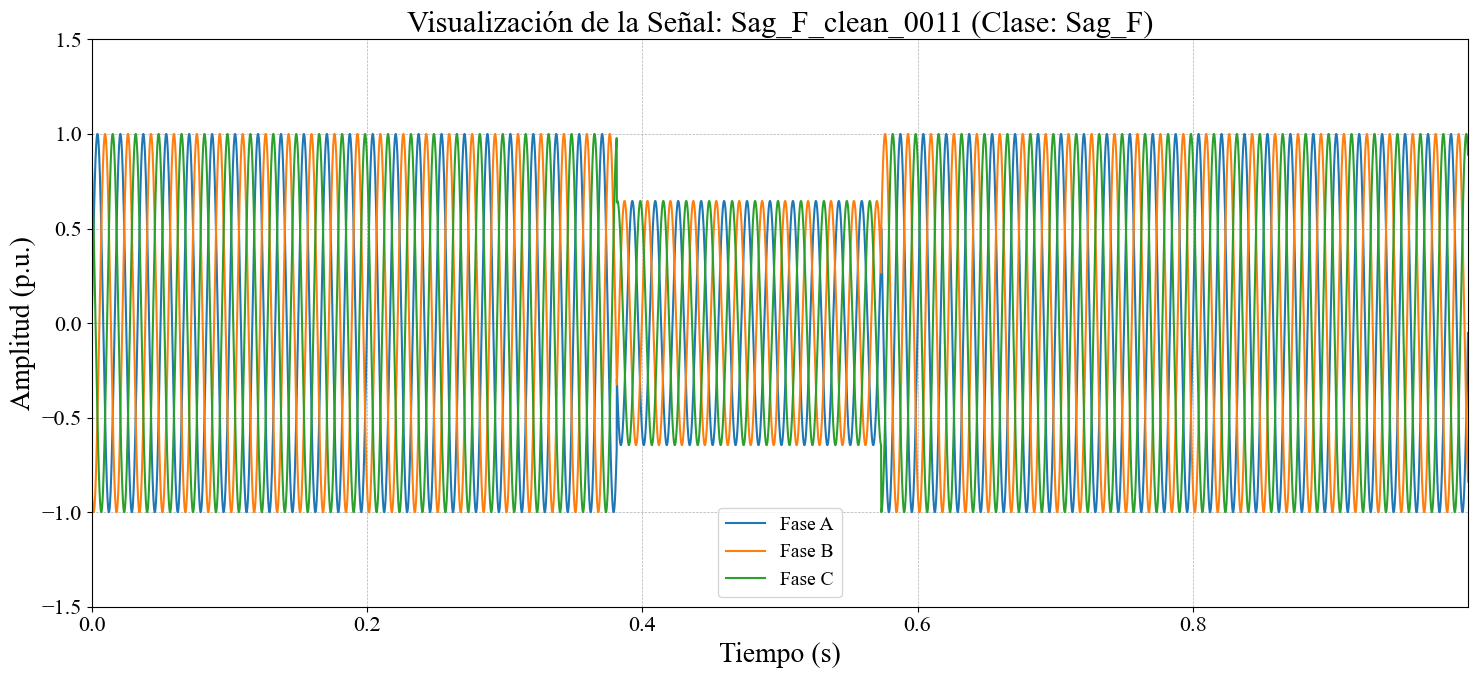

Cargando el dataset desde: Dataset_Trifasico_5.parquet...
Buscando y graficando la señal con ID: Sag_G_clean_0011...


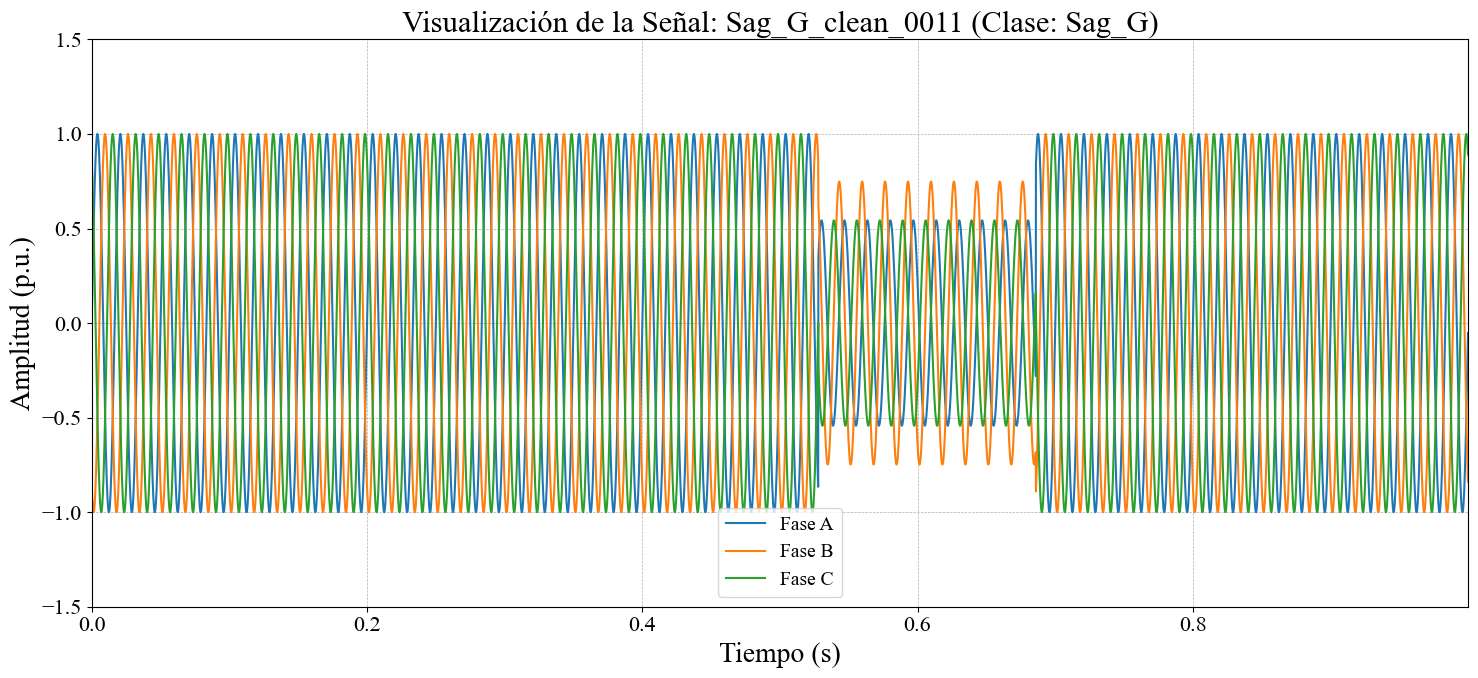

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def _setup_academic_style():
    """Configura los parámetros de Matplotlib para un estilo tipo IEEE."""
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.size'] = 14
    plt.rcParams['axes.labelsize'] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['xtick.labelsize'] = 16 # Ajustado para mejor legibilidad
    plt.rcParams['ytick.labelsize'] = 16
    plt.rcParams['legend.fontsize'] = 14 # Ajustado para el tamaño de la leyenda
    plt.rcParams['lines.linewidth'] = 1.5
    # El tamaño de la figura se definirá en la función de ploteo para mayor flexibilidad

def plot_signal_by_id(file_path, signal_id):
    """
    Carga un dataset de señales y grafica un evento específico por su ID.
    """
    print(f"Cargando el dataset desde: {file_path}...")
    try:
        if file_path.endswith('.parquet'):
            df = pd.read_parquet(file_path)
        else:
            df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo en la ruta: {file_path}")
        return
        
    print(f"Buscando y graficando la señal con ID: {signal_id}...")
    
    signal_df = df[df['signal_id'] == signal_id].copy()
    
    if signal_df.empty:
        print(f"Error: No se encontró la señal con el ID '{signal_id}'.")
        return

    etiqueta = signal_df['etiqueta'].iloc[0]

    # --- Creación del Gráfico ---
    # Se usa un tamaño de figura más panorámico, ideal para series de tiempo
    plt.figure(figsize=(15, 7))
    
    plt.plot(signal_df['timestamp'], signal_df['Phase_A'], label='Fase A')
    plt.plot(signal_df['timestamp'], signal_df['Phase_B'], label='Fase B')
    plt.plot(signal_df['timestamp'], signal_df['Phase_C'], label='Fase C')
    
    # Los tamaños de fuente ahora son controlados por rcParams
    plt.title(f'Visualización de la Señal: {signal_id} (Clase: {etiqueta})')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (p.u.)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xlim(0, max(signal_df['timestamp']))
    plt.ylim(-1.5, 1.5)
    plt.tight_layout() # Ajusta el layout para que no se corten las etiquetas
    plt.show()

# ==============================================================================
# --- ÁREA DE EJECUCIÓN ---
# ==============================================================================
if __name__ == "__main__":
    
    # 1. Aplicamos el estilo académico a todos los gráficos generados
    _setup_academic_style()

    # 2. Define la ruta a tu archivo de dataset
    DATASET_PATH = "Dataset_Trifasico_5.parquet"

    # 3. Elige el ID de la señal que quieres graficar
    id_a_graficar = "Sag_A_clean_0011" ## Sag_A_noisy_1000 para ruido y Sag_A_clean_1000 sin ruido
    id_a_graficar_2 = "Sag_B_clean_0011"
    id_a_graficar_3 = "Sag_C_clean_0011"
    id_a_graficar_4 = "Sag_D_clean_0011"
    id_a_graficar_5 = "Sag_E_clean_0011"
    id_a_graficar_6 = "Sag_F_clean_0011"
    id_a_graficar_7 = "Sag_G_clean_0011"
    # 4. Llama a la función para graficar
    plot_signal_by_id(DATASET_PATH, id_a_graficar)
    plot_signal_by_id(DATASET_PATH, id_a_graficar_2)
    plot_signal_by_id(DATASET_PATH, id_a_graficar_3)
    plot_signal_by_id(DATASET_PATH, id_a_graficar_4)
    plot_signal_by_id(DATASET_PATH, id_a_graficar_5)
    plot_signal_by_id(DATASET_PATH, id_a_graficar_6)
    plot_signal_by_id(DATASET_PATH, id_a_graficar_7)

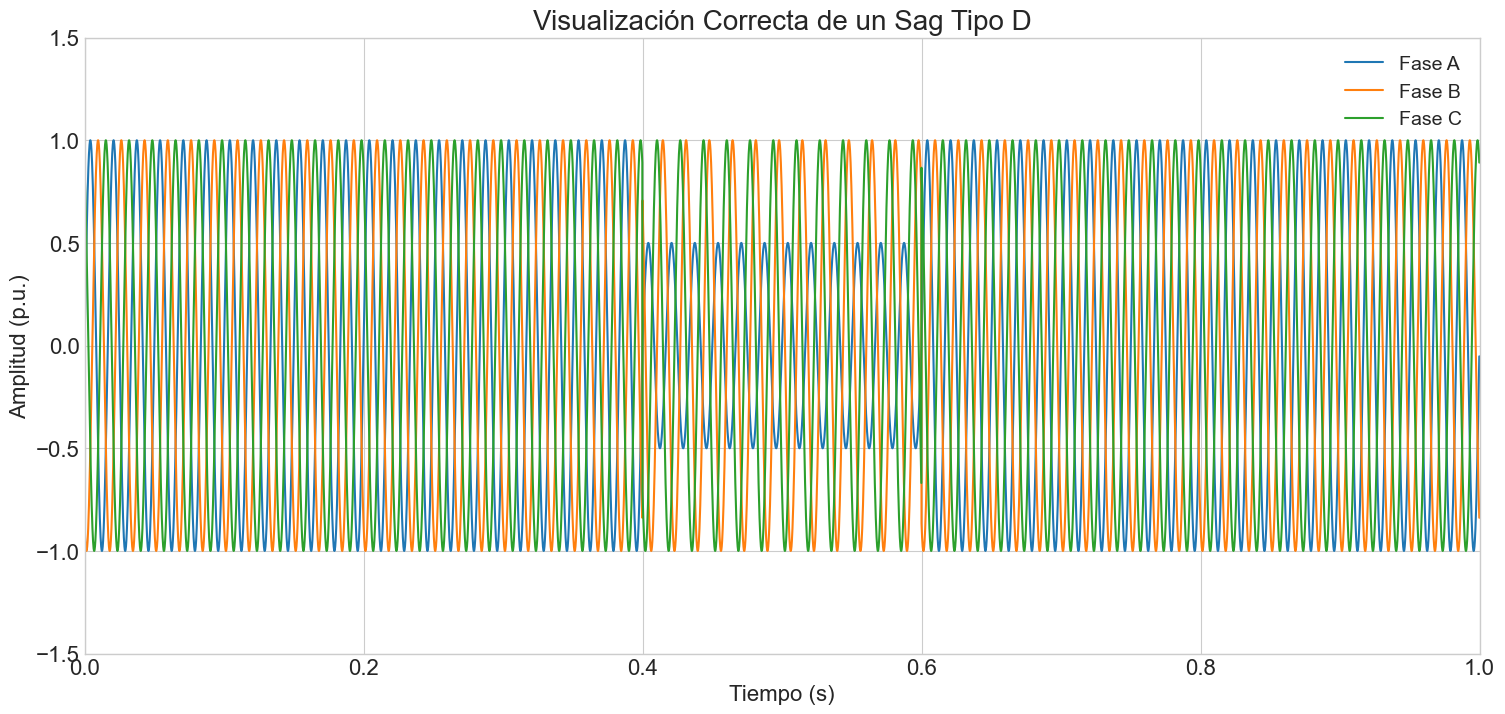

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cmath

# --- 1. PARÁMETROS DE LA SEÑAL ---
FS = 7200
FREQ = 60
AMPLITUDE = 1.0
DURATION = 1
V = 0.5 # Profundidad del sag para la fase A

# --- 2. FUNCIÓN DE GENERACIÓN CORREGIDA ---
def generar_y_graficar_sag_tipo_D():
    """
    Genera y grafica una señal de sag Tipo D correctamente, donde una
    fase cae y las otras dos se desfasan manteniendo su magnitud.
    """
    t = np.linspace(0, DURATION, int(FS * DURATION), endpoint=False)

    # Definir el intervalo del evento
    start_time = 0.4
    end_time = 0.6
    u = (t >= start_time) & (t < end_time)

    # Generar señal base
    va_sag = AMPLITUDE * np.sin(2 * np.pi * FREQ * t)
    vb_sag = AMPLITUDE * np.sin(2 * np.pi * FREQ * t - 2 * np.pi / 3)
    vc_sag = AMPLITUDE * np.sin(2 * np.pi * FREQ * t + 2 * np.pi / 3)

    # ========================================================================
    # =========== ¡FASORES CORRECTOS PARA UN SAG TIPO D! =============
    # ========================================================================
    # Va cae a V. Vb y Vc mantienen magnitud 1.0 pero se desfasan un ángulo 'delta'.
    # Este es un ejemplo físico realista de este tipo de falla.
    
    # Pequeño desfase adicional para las fases sanas (en radianes)
    fase_shift_delta = np.deg2rad(15) 
    
    phasors_tipo_D = {
        'A': V,
        'B': 1.0 * cmath.exp(1j * (-2*np.pi/3 + fase_shift_delta)),
        'C': 1.0 * cmath.exp(1j * ( 2*np.pi/3 - fase_shift_delta))
    }
    
    # Extraer magnitud y ángulo de cada fasor
    mag_a, ang_a = cmath.polar(phasors_tipo_D['A'])
    mag_b, ang_b = cmath.polar(phasors_tipo_D['B'])
    mag_c, ang_c = cmath.polar(phasors_tipo_D['C'])

    # ========================================================================
    # =========== ¡APLICACIÓN DE ÁNGULOS 100% CORREGIDA! =============
    # ========================================================================
    # Aplicar el sag SÓLO durante el intervalo 'u'
    va_sag[u] = AMPLITUDE * mag_a * np.sin(2 * np.pi * FREQ * t[u] + ang_a)
    vb_sag[u] = AMPLITUDE * mag_b * np.sin(2 * np.pi * FREQ * t[u] - (2*np.pi/3) + ang_b)
    vc_sag[u] = AMPLITUDE * mag_c * np.sin(2 * np.pi * FREQ * t[u] + (2*np.pi/3) + ang_c)
    
    # --- 3. GRAFICAR EL RESULTADO ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(18, 8))
    
    ax.plot(t, va_sag, label='Fase A', lw=1.5)
    ax.plot(t, vb_sag, label='Fase B', lw=1.5)
    ax.plot(t, vc_sag, label='Fase C', lw=1.5)
    
    ax.set_title('Visualización Correcta de un Sag Tipo D', fontsize=20)
    ax.set_xlabel('Tiempo (s)', fontsize=16)
    ax.set_ylabel('Amplitud (p.u.)', fontsize=16)
    ax.legend(fontsize=14)
    ax.set_xlim(0, DURATION)
    ax.set_ylim(-1.5, 1.5)
    
    plt.show()

# --- EJECUTAR EL SCRIPT ---
if __name__ == "__main__":
    generar_y_graficar_sag_tipo_D()